#LABORATORIO 1: Algoritmos Genéticos


#PARTE TEÓRICA

<b>(4 ptos)</b> 1. Explique brevemente los siguientes conceptos relacionados al algoritmo genético.

1. Cromosoma
2. Gen
3. Alelo
4. Fitness

    Rpta:
    1. Cromosoma: Es el arreglo que identifica la solucion unica asociada al individuo
    2. Gen: Es cada una de las caracteristicas del cromosoma
    3. Alelo: Son todas las opciones disponibles que puede tomar el gen
    4. Fitness: Es la funcion que permite validar el rendimiento de un individuo, basado en su cromosoma

<b>(6 ptos)</b> 2. Describa brevemente (1 línea) las siguientes etapas del algoritmo genético.

1. Inicialización
2. Evaluación
3. Selección de padres
4. Cruzamiento
5. Mutación
6. Selección de sobrevivientes

    Rpta:
    1. Inicialización: Se inicializa de forma aleatoria un numero concreto N de individuos cada uno con su cromosoma.
    2. Evaluación: Se realiza una evaluacion de la poblacion inicial en base a la funcion de fitness
    3. Selección de padres: Se selecciona un par de padres basado en el criterio seleccionado.
    4. Cruzamiento: Los padres seleccionados entrecruzaran sus cromosomas, en base al criterio seleccionado, lo cual generara dos nuevos individuos.
    5. Mutación: Se selecciona un individuo aleatorio o en base a un criterio, el cual sera sometido a la mutacion de uno o mas de sus genes, en base al criterio seleccionado.
    6. Selección de sobrevivientes: Finalmente, se unen las poblaciones ( inicial e hijo) dando paso a una seleccion basada en seleccionar aquellos N con mayor rendimiento (fitness)

#PARTE PRÁCTICA

El problema de la mochila o "knapsack problem" es un tipo de problema de optimización combinatoria. Se puede definir como: dado un conjunto de items, cada uno con un peso y un valor, determinar una colección de articulos cuyo valor total sea lo más grande posible, pero el peso total no sobrepase un límite dado. Este problema hace recordar al problema que enfrenta una persona que quiere llenar una mochila con los elementos más valiosos pero está limitado por la capacidad de la mochila.

En este notebook se presenta una implementación basada en algoritmos genéticos para resolver el problema de la mochila y ver como los operadores genéticos influyen en el desempeño del algoritmo.

La clase individuo tiene implementado los siguientes operadores: cruzamiento de un punto (crossover_onepoint), cruzamiento uniforme (crossover_uniform), operador de mutacion de una posicion (mutation_flip).

<p><img src="https://upload.wikimedia.org/wikipedia/commons/f/fd/Knapsack.svg">

### librerias a usar

In [1]:
import sys
import time
import numpy as np
import random
from copy import deepcopy
import matplotlib.pyplot as plt

### Define el objeto Item en el problema de la mochila
Un objeto de clase Item almacena el valor del item y el peso del item

In [2]:
class Item(object):
    def __init__(self, value, weight):
        self.value  = value  # Valor del item. La suma de los valores de los items es lo que se quiere maximizar
        self.weight = weight # Peso del item. Se impone una restriccion en el peso maximo de una mochila

### Define la estructura de un individuo en el AG con sus operadores genéticos

Implementa el individuo del AG. Un individuo tiene un cromosoma que es una lista de NUM_ITEMS elementos (genes),
cada gen i puede asumir dos posibles alelos: 0 o 1 (no incluir/incluir en la mochila el item i del pool)


In [27]:
class Individual:

    def __init__(self, chromosome):  # el constructor recibe un cromosoma
        self.chromosome = chromosome[:]
        self.fitness = -1  # -1 indica que el individuo no ha sido evaluado

    def crossover_onepoint(self, other):
        "Retorna dos nuevos individuos del cruzamiento de un punto entre individuos self y other "
        c = random.randrange(len(self.chromosome))
        ind1 = Individual(self.chromosome[:c] + other.chromosome[c:])
        ind2 = Individual(other.chromosome[:c] + self.chromosome[c:])
        return [ind1, ind2]

    def crossover_twopoint(self, other):
        """
        Elige dos puntos de corte distintos al azar dentro del cromosoma, y luego intercambia
        el segmento comprendido entre esos dos puntos entre los padres para generar nuevos individuos.

        Los puntos de corte deben cumplir: 0 <= c1 < c2 <= len(chromosome)

        El proceso consiste en:
        - Copiar el inicio del primer padre hasta c1
        - Copiar el segmento intermedio del segundo padre desde c1 hasta c2
        - Copiar el final del primer padre desde c2 hasta el final

        Se generan dos hijos intercambiando los roles de los padres.

        Por ejemplo:
        Padre 1: [1, 0, 1, 1, 0, 0, 1, 0]
        Padre 2: [0, 1, 0, 0, 1, 1, 0, 1]

        Supongamos que los puntos de corte son c1=2 y c2=6:

        Segmentos:
        Padre 1: [1, 0 | 1, 1, 0, 0 | 1, 0]
        Padre 2: [0, 1 | 0, 0, 1, 1 | 0, 1]

        Hijo 1:
        - Inicio de Padre 1 → [1, 0]
        - Medio de Padre 2 → [0, 0, 1, 1]
        - Final de Padre 1 → [1, 0]
        Resultado: [1, 0, 0, 0, 1, 1, 1, 0]

        Hijo 2:
        - Inicio de Padre 2 → [0, 1]
        - Medio de Padre 1 → [1, 1, 0, 0]
        - Final de Padre 2 → [0, 1]
        Resultado: [0, 1, 1, 1, 0, 0, 0, 1]
        """
        n = len(self.chromosome)
        # Elegir dos puntos distintos y ordenarlos
        c1, c2 = sorted(random.sample(range(n), 2))

        ## ESCRIBIR AQUI SU CODIGO
        new_chrom1 = self.chromosome[:c1] + other.chromosome[c1:c2] + self.chromosome[c2:]
        new_chrom2 = other.chromosome[:c1] + self.chromosome[c1:c2] + other.chromosome[c2:]

        ind1 = Individual(new_chrom1)
        ind2 = Individual(new_chrom2)

        return [ind1, ind2]

    def crossover_uniform(self, other):
        chromosome1 = []
        chromosome2 = []
        "Retorna dos nuevos individuos del cruzamiento uniforme entre self y other"
        for i in range(len(self.chromosome)):
            if random.uniform(0, 1) < 0.5:
                chromosome1.append(self.chromosome[i])
                chromosome2.append(other.chromosome[i])
            else:
                chromosome1.append(other.chromosome[i])
                chromosome2.append(self.chromosome[i])
        ind1 = Individual(chromosome1)
        ind2 = Individual(chromosome2)
        return [ind1, ind2]

    def mutation_flip(self):
        "Cambia aleatoriamente el alelo de un gen."
        new_chromosome = deepcopy(self.chromosome)
        mutGene = random.randrange(0,len(new_chromosome))   # escoge un gen para mutar
        if new_chromosome[mutGene] == 0:
            new_chromosome[mutGene] = 1
        else:
            new_chromosome[mutGene] = 0
        return Individual(new_chromosome)

    def mutation_flip_k(self, k):
        """
        Elige k genes al azar, y cambia el alelo de 0 a 1, o 1 a 0.
        Donde 'k' es el número de genes a mutar (1 <= k <= len(chromosome))

        Por ejemplo:
        Individuo original: [1, 0, 1, 1, 0, 0, 1, 0]
        Con k=3 y asumiendo que los genes seleccionados al azar son los de posición [1, 4, 6], el individuo mutaría así:
        Genes a mutar: [1, (0), 1, 1, (0), 0, (1), 0]
        Individuo mutado: [1, 1, 1, 1, 1, 0, 0, 0]
        """
        new_chromosome = deepcopy(self.chromosome)

        ## ESCRIBIR AQUI SU CODIGO
        idx_to_change = random.sample(range(len(self.chromosome)), k)

        for idx in idx_to_change:
          if new_chromosome[idx] == 0:
            new_chromosome[idx] = 1
          else:
            new_chromosome[idx] = 0

        return Individual(new_chromosome)


### Funcion para obtener el fitness de un cromosoma

In [220]:
def get_fitness(chromosome, items, max_weight):
    """Retorna el fitness del cromosoma pasado. Fitness es el valor total de los items incluidos en el cromosoma
       Si el peso total es mayor que max_weight -> el fitness es 1"""
    fitness = 0 # initialize fitness to 0
    sum_weight = 0

    for i in range(len(items)):
        if chromosome[i] == 1:  # si item i esta incluido en cromosoma, acumula su valor y peso
            fitness += items[i].value
            sum_weight += items[i].weight
            if  sum_weight > max_weight: # si se paso del peso maximo retorna 1 como fitness
                return 1
    return fitness

### Funcion para evaluar una población de individuos

In [29]:
def evaluate_population(population, items, max_weight):
    """ Evalua una poblacion de individuos con la funcion get_fitness """
    popsize = len(population)
    for i in range(popsize):
        if population[i].fitness == -1:    # evalua solo si el individuo no esta evaluado
            population[i].fitness = get_fitness(population[i].chromosome, items, max_weight)

### Funcion para inicializar aleatoriamente una población de individuos

In [30]:
def init_population(popsize, chromosome_size, zeroes=False):
    """Inicializa una poblacion de popsize individuos, cada cromosoma de individuo de tamaño chromosome_size.
       Si zeroes==False La inicializacion es aleatoria (por defecto), si zeroes=True los cromosomas son vectores de ceros"""
    population = []
    for i in range(popsize):
        if zeroes:
            new_chromosome = [0 for j in range(chromosome_size)]  # vector de zeros de tamaño chromosome_size
        else:
            new_chromosome = [random.randint(0,1) for j in range(chromosome_size)]  #vector aleatorio de 0s y 1s de tamaño chromosome_size

        population.append( Individual(new_chromosome) )
    return population

### Operadores de seleccion de padres

#### Seleccion por Ruleta

In [31]:
def select_parents_roulette(population):
    popsize = len(population)

    # Escoje el primer padre
    sumfitness = sum([indiv.fitness for indiv in population])  # suma total del fitness de la poblacion
    pickfitness = random.uniform(0, sumfitness)   # escoge un numero aleatorio entre 0 y sumfitness
    cumfitness = 0     # fitness acumulado
    for i in range(popsize):
        cumfitness += population[i].fitness
        if cumfitness > pickfitness:
            iParent1 = i
            break

    # Escoje el segundo padre, desconsiderando el primer padre
    sumfitness = sumfitness - population[iParent1].fitness # retira el fitness del padre ya escogido
    pickfitness = random.uniform(0, sumfitness)   # escoge un numero aleatorio entre 0 y sumfitness
    cumfitness = 0     # fitness acumulado
    for i in range(popsize):
        if i == iParent1: continue   # si es el primer padre
        cumfitness += population[i].fitness
        if cumfitness > pickfitness:
            iParent2 = i
            break
    return (population[iParent1], population[iParent2])

#### Seleccion por Torneo

In [32]:
def select_parents_tournament(population, tournament_size):
    # Escoje el primer padre
    list_indiv=[]
    x1 = np.random.permutation(len(population) )
    y1= x1[0:tournament_size]
    for i in range(tournament_size):
        list_indiv.append(population[y1[i]].fitness)

    iParent1=np.argmax(list_indiv)

    # Escoje el segundo padre, desconsiderando el primer padre
    x2 = np.delete(x1, iParent1)
    x2 = np.random.permutation(x2)
    list_indiv=[]
    y2= x2[0:tournament_size]
    for i in range(tournament_size):
        list_indiv.append(population[y2[i]].fitness)
    iParent2=np.argmax(list_indiv)

    return (population[x1[iParent1]],population[x2[iParent2]])

### Operadores de Seleccion de sobrevivientes


#### Función de selección de la poblacion para la sgte generación por ranking
Selecciona la población siguiente ranqueando los individuos de la poblacion actual (population) y la poblacion descendencia (offspring_population) y escogiendo los mejores numsurvivors  individuos

In [33]:
def select_survivors_ranking(population, offspring_population, numsurvivors):
    next_population = []
    population.extend(offspring_population) # une las dos poblaciones
    isurvivors = sorted(range(len(population)), key=lambda i: population[i].fitness, reverse=True)[:numsurvivors]
    for i in range(numsurvivors):
        next_population.append(population[isurvivors[i]])
    return next_population

### Algoritmo Genetico para encontrar soluciones al problema de la mochila
Recibe una poblacion inicial, lista de items, maximo peso de la mochila (max_weight), numero de generaciones (ngen), taza de mutación (pmut), operador de cruzamiento (crossover), operador de mutacion (mutation), metodo de seleccion de padres (selection_parents_method), metodo de seleccion de sobrevivientes (selection_survivors_method)

In [45]:
def genetic_algorithm(population, items, max_weight, ngen=100, pmut=0.1,
                      crossover="onepoint", mutation="flip", k=3,
                      selection_parents_method="roulette",
                      selection_survivors_method="ranking"):
    """Algoritmo Genetico para el problema de la mochila
        items:      pool de items a escoger para la mochila.
                    Debe ser una lista de objetos de clase Item
        max_weight: maximo peso que puede soportar la mochila
        ngen:       maximo numero de generaciones
        pmut:       tasa de mutacion
        crossover:  operador de cruzamiento
        mutation:   operador de mutacion
        selection_parents_method: método de selección de padres para cruzamiento
        selection_survivors_method: método de selección de sobrevivientes
    """

    popsize = len(population)
    evaluate_population(population, items, max_weight)  # evalua la poblacion inicial
    ibest = sorted(range(len(population)), key=lambda i: population[i].fitness, reverse=True)[:1]  # mejor individuo
    bestfitness = [population[ibest[0]].fitness]  # fitness del mejor individuo
    print("Poblacion inicial, best_fitness = {}".format(population[ibest[0]].fitness))
    best_fitnesss = 0
    for g in range(ngen):   # Por cada generacion

        ## Selecciona parejas de individuos (mating_pool) para cruzamiento con el metodo de la ruleta
        mating_pool = []
        for i in range(int(popsize/2)):
            if selection_parents_method == "roulette":
                mating_pool.append(select_parents_roulette(population))
            elif selection_parents_method == "tournament":
                mating_pool.append(select_parents_tournament(population, 3))
            else:
                raise NotImplementedError
        ## Crea la poblacion descendencia cruzando las parejas del mating pool
        offspring_population = []
        for i in range(len(mating_pool)):
            if crossover == "onepoint":
                offspring_population.extend( mating_pool[i][0].crossover_onepoint(mating_pool[i][1]) ) # cruzamiento 1 punto
            elif crossover == "twopoint":
                offspring_population.extend( mating_pool[i][0].crossover_twopoint(mating_pool[i][1]) ) # cruzamiento 2 puntos
            elif crossover == "uniform":
                offspring_population.extend( mating_pool[i][0].crossover_uniform(mating_pool[i][1]) ) # cruzamiento uniforme
            else:
                raise NotImplementedError

        ## Aplica el operador de mutacion con probabilidad pmut en cada hijo generado
        for i in range(len(offspring_population)):
            if random.uniform(0, 1) < pmut:
                if mutation == "flip":
                    offspring_population[i] = offspring_population[i].mutation_flip() # cambia el alelo de un gen
                elif mutation == "flip_k":
                    offspring_population[i] = offspring_population[i].mutation_flip_k(k) # cambia el alelo de k genes
                else:
                    raise NotImplementedError

        ## Evalua la poblacion descendencia creada
        evaluate_population(offspring_population, items, max_weight)   # evalua la poblacion descendencia

        ## Selecciona individuos para la sgte. generación
        if selection_survivors_method == "ranking":
            population = select_survivors_ranking(population, offspring_population, popsize) #metodo de ranking
        else:
            raise NotImplementedError

        ## Almacena la historia del fitness del mejor individuo
        ibest = sorted(range(len(population)), key=lambda i: population[i].fitness, reverse=True)[:1]
        bestfitness.append(population[ibest[0]].fitness)
        best_fitness_gen = population[ibest[0]].fitness

        if best_fitnesss < best_fitness_gen:  # muestra resultados cada 10 generaciones
            print("generacion {}, (Mejor fitness = {})".format(g, population[ibest[0]].fitness))
            best_fitnesss = best_fitness_gen

    print("Mejor individuo en la ultima generacion = {} (fitness = {})".format(population[ibest[0]].chromosome, population[ibest[0]].fitness))
    return population[ibest[0]], bestfitness  # devuelve el mejor individuo y la lista de mejores fitness x gen

 ## Probando el Algoritmo genetico

<b>Define el pool de items disponibles y capacidad de la mochila</b>

In [35]:
NUM_ITEMS = 60        # numero de items
MAX_ITEM_WEIGHT = 60  # maximo peso posible de cada  item
MAX_ITEM_VALUE = 60   # maximo valor posible de cada  item
#pool de items generado aleatoriamente
ItemPool = [ Item(random.randint(0,MAX_ITEM_VALUE), random.randint(0,MAX_ITEM_WEIGHT)) for x in range (0,NUM_ITEMS)]
MAX_WEIGHT = 10*len(ItemPool)    # maximo peso que puede soportar la mochila

<b> Ejecuta el algoritmo genetico </b>

Poblacion inicial, best_fitness = 663
generacion 0, (Mejor fitness = 727)
generacion 10, (Mejor fitness = 911)
generacion 20, (Mejor fitness = 1035)
generacion 30, (Mejor fitness = 1098)
generacion 40, (Mejor fitness = 1101)
generacion 50, (Mejor fitness = 1101)
generacion 60, (Mejor fitness = 1101)
generacion 70, (Mejor fitness = 1101)
generacion 80, (Mejor fitness = 1101)
generacion 90, (Mejor fitness = 1101)
generacion 100, (Mejor fitness = 1101)
generacion 110, (Mejor fitness = 1101)
generacion 120, (Mejor fitness = 1101)
generacion 130, (Mejor fitness = 1101)
generacion 140, (Mejor fitness = 1101)
generacion 150, (Mejor fitness = 1101)
generacion 160, (Mejor fitness = 1101)
generacion 170, (Mejor fitness = 1101)
generacion 180, (Mejor fitness = 1101)
generacion 190, (Mejor fitness = 1101)
generacion 200, (Mejor fitness = 1101)
generacion 210, (Mejor fitness = 1101)
generacion 220, (Mejor fitness = 1101)
generacion 230, (Mejor fitness = 1101)
generacion 240, (Mejor fitness = 1101)


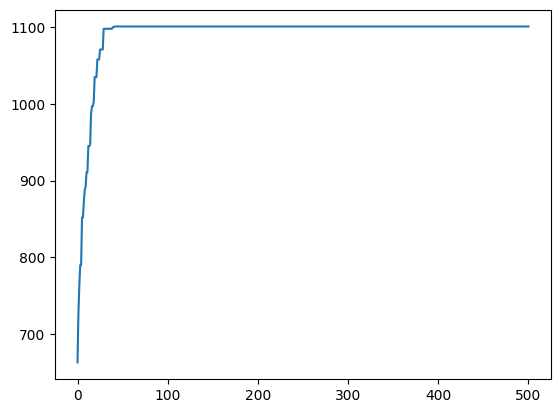

In [36]:
## Hiperparametros del algoritmo genetico
POPSIZE = 50       # numero de individuos
GENERATIONS = 500   # numero de generaciones
PMUT = 0.5       # taza de mutacion

## Inicializa una poblacion inicial de forma aleatoria
population = init_population(POPSIZE, NUM_ITEMS)
# Evolue la poblacion con el algoritmo genetico (cruzamiento 'onepoint', )
best_ind, bestfitness = genetic_algorithm(population, ItemPool, MAX_WEIGHT, GENERATIONS, PMUT, crossover="uniform",
                                          mutation="flip", selection_parents_method = 'roulette', k=3,
                                          selection_survivors_method = 'ranking')

# muestra la evolucion del mejor fitness
plt.plot(bestfitness)
plt.show()


##PREGUNTAS

<b>(2 ptos)</b> 3. Implemente el método `crossover_twopoint` en la clase `Individual`.

<b>(2 ptos)</b> 4. Implemente el método `mutation_flip_k` en la clase `Individual`.

<b>(3 ptos) </b>5. Compare el desempeño de los operadores de cruzamiento.

Se debe colocar la `tasa de mutación = 0` (a fin de centrarnos solo en el efecto de cruzamiento) y ejecutar el algoritmo genético con `50 individuos`, `300 generaciones` para cada una de las siguientes configuraciones:

- Operador de `Cruzamiento onepoint` y `selección por el metodo de la ruleta`
- Operador de `Cruzamiento twopoint` y `selección por el metodo de la ruleta`
- Operador de `Cruzamiento uniform` y `selección por el metodo de la ruleta`

Muestre el fitness máximo obtenido con cada configuración, asi como la generación de convergencia (la primera generacion donde se obtiene el fitness máximo). Indique con cuál o cuáles configuraciones se obtiene mayor fitness y mayor rapidez de convergencia, y explique cómo influye el operador de cruzamiento en los resultados.

<b>RESPUESTA</b>

In [60]:
NUM_ITEMS = 60        # numero de items
MAX_ITEM_WEIGHT = 60  # maximo peso posible de cada  item
MAX_ITEM_VALUE = 60   # maximo valor posible de cada  item
#pool de items generado aleatoriamente
ItemPool = [ Item(random.randint(0,MAX_ITEM_VALUE), random.randint(0,MAX_ITEM_WEIGHT)) for x in range (0,NUM_ITEMS)]
MAX_WEIGHT = 10*len(ItemPool)    # maximo peso que puede soportar la mochila

## Hiperparametros del algoritmo genetico
POPSIZE = 50       # numero de individuos
GENERATIONS = 300   # numero de generaciones
PMUT = 0       # taza de mutacion

## Inicializa una poblacion inicial de forma aleatoria
population_init = init_population(POPSIZE, NUM_ITEMS)

Poblacion inicial, best_fitness = 721
generacion 0, (Mejor fitness = 796)
generacion 2, (Mejor fitness = 853)
generacion 3, (Mejor fitness = 886)
Mejor individuo en la ultima generacion = [1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1] (fitness = 886)


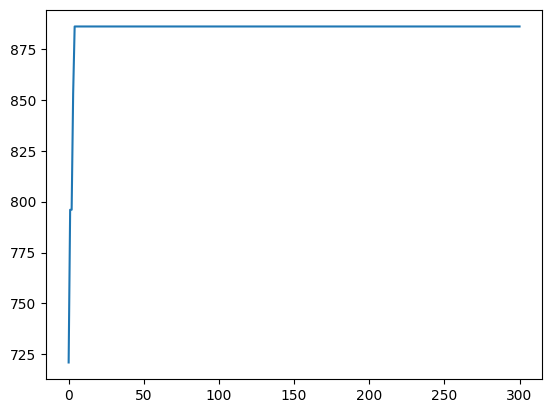

In [63]:
# CRUZAMIENTO ONEPOINT
population = population_init.copy()
# Evolue la poblacion con el algoritmo genetico (cruzamiento 'onepoint', )
best_ind, bestfitness = genetic_algorithm(population, ItemPool, MAX_WEIGHT, GENERATIONS, PMUT, crossover="onepoint",
                                          mutation="flip", selection_parents_method = 'roulette', k=3,
                                          selection_survivors_method = 'ranking')

# muestra la evolucion del mejor fitness
plt.plot(bestfitness)
plt.show()

Poblacion inicial, best_fitness = 721
generacion 0, (Mejor fitness = 792)
generacion 2, (Mejor fitness = 803)
generacion 4, (Mejor fitness = 830)
generacion 5, (Mejor fitness = 844)
generacion 6, (Mejor fitness = 849)
generacion 10, (Mejor fitness = 869)
generacion 14, (Mejor fitness = 879)
Mejor individuo en la ultima generacion = [1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1] (fitness = 879)


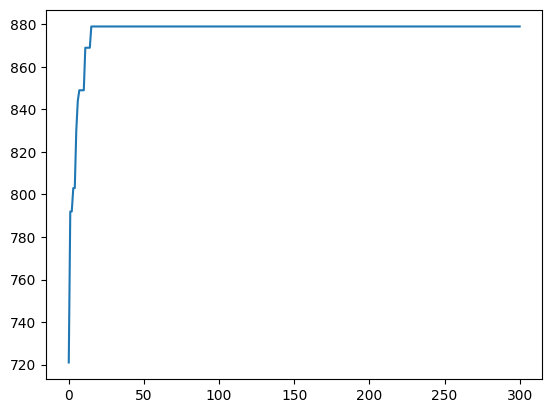

In [66]:
# CRUZAMIENTO TWOPOINT
population = population_init.copy()
# Evolue la poblacion con el algoritmo genetico (cruzamiento 'onepoint', )
best_ind, bestfitness = genetic_algorithm(population, ItemPool, MAX_WEIGHT, GENERATIONS, PMUT, crossover="twopoint",
                                          mutation="flip", selection_parents_method = 'roulette', k=3,
                                          selection_survivors_method = 'ranking')

# muestra la evolucion del mejor fitness
plt.plot(bestfitness)
plt.show()

Poblacion inicial, best_fitness = 721
generacion 0, (Mejor fitness = 742)
generacion 1, (Mejor fitness = 794)
generacion 2, (Mejor fitness = 880)
generacion 4, (Mejor fitness = 884)
generacion 6, (Mejor fitness = 919)
generacion 7, (Mejor fitness = 936)
generacion 10, (Mejor fitness = 973)
generacion 11, (Mejor fitness = 1009)
generacion 15, (Mejor fitness = 1056)
generacion 22, (Mejor fitness = 1074)
Mejor individuo en la ultima generacion = [1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1] (fitness = 1074)


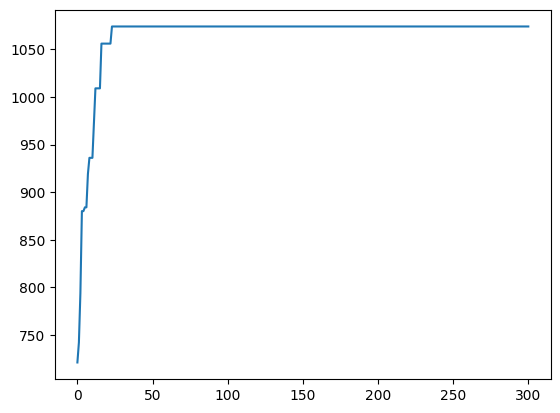

In [69]:
# CRUZAMIENTO UNIFORM
population = population_init.copy()
# Evolue la poblacion con el algoritmo genetico (cruzamiento 'onepoint', )
best_ind, bestfitness = genetic_algorithm(population, ItemPool, MAX_WEIGHT, GENERATIONS, PMUT, crossover="uniform",
                                          mutation="flip", selection_parents_method = 'roulette', k=3,
                                          selection_survivors_method = 'ranking')

# muestra la evolucion del mejor fitness
plt.plot(bestfitness)
plt.show()

Fitness inicial = 721

HISTORIAL:
1.   OnePoint
*   Corr1: Gen8- Fitness 900
*   Corr2: Gen0 - Fitness 721
*   __Corr3: Gen3 - Fitness 886__

2.   TwoPoint
*   Corr1: Gen1 - Fitness 788
*   Corr2: Gen7 - Fitness 830
*   __Corr3: Gen14 - Fitness 879__

3.   Uniform
*   Corr1: Gen19 - Fitness 1018
*   Corr2: Gen18 - Fitness 928
*   __Corr3: Gen22 - Fitness 1074__

El mayor fitness se logra obtener con el metodo de cruzamiento 'Uniform', mientras que con el metodo 'OnePoint' se alcanza la convergencia en un menor numero de generaciones.

El criterio de 'Uniform' a diferencia de los otros dos permite probar combinaciones más diversas, debido a que se entrelazan gen a gen, a diferencia de los otros, que intercambian secciones del cromosoma. La generación de individuos que presentan cromosomas más diferenciados permite al algoritmo probar nuevas combinaciones y, por ende, alcanzar combinaciones que presentan un mayor fitness.
Por otro lado, el criterio de 'OnePoint' alcanza con mayor rapidez la convergencia debido a su bajo factor de variabilidad. Al solo intercambiar secciones entre los Indiviuos padres, tiende a estancarse en soluciones desde una temprana ejecucion, debido a que los hijos tenderan a ser similares a los padres con una baja diversidad y, por ende, bajas probabilidades de presentar mejores fitness. El criterio 'TwoPoint' presenta las mismas limitaciones mencionadas anteriormente, con la diferencia que el intercambio de un mayor numero de secciones permite probar una mayor cantidad y más variada de posibles soluciones.


<b>(3 ptos)</b> 6. Determine la influencia de la mutación.

Con el mejor operador de cruzamiento identificado en la pregunta anterior, ejecute el algoritmo genético con `10 individuos`, `300 generaciones` y las siguientes configuraciones:

- Operador de `mutación flip` y `tasa de mutación 20%`
- Operador de `mutación flip` y `tasa de mutación 80%`
- Operador de `mutación flip-k` (con k=50) y `tasa de mutación 20%`
- Operador de `mutación flip-k` (con k=50) y `tasa de mutación 80%`

Muestre el fitness máximo obtenido con cada configuración, asi como la generación de convergencia (la primera generacion donde se obtiene el fitness máximo). Indique con cuál o cuáles configuraciones se obtiene mayor fitness y mayor rapidez de convergencia, y explique cómo influye el operador de mutación y la tasa de mutación en los resultados.

In [117]:
NUM_ITEMS = 60        # numero de items
MAX_ITEM_WEIGHT = 60  # maximo peso posible de cada  item
MAX_ITEM_VALUE = 60   # maximo valor posible de cada  item
#pool de items generado aleatoriamente
ItemPool = [ Item(random.randint(0,MAX_ITEM_VALUE), random.randint(0,MAX_ITEM_WEIGHT)) for x in range (0,NUM_ITEMS)]
MAX_WEIGHT = 10*len(ItemPool)    # maximo peso que puede soportar la mochila

## Hiperparametros del algoritmo genetico
POPSIZE = 10       # numero de individuos
GENERATIONS = 300   # numero de generaciones

## Inicializa una poblacion inicial de forma aleatoria
population_init = init_population(POPSIZE, NUM_ITEMS)

Poblacion inicial, best_fitness = 1
generacion 0, (Mejor fitness = 1)
generacion 194, (Mejor fitness = 741)
generacion 199, (Mejor fitness = 788)
generacion 201, (Mejor fitness = 799)
generacion 203, (Mejor fitness = 800)
generacion 216, (Mejor fitness = 814)
generacion 221, (Mejor fitness = 869)
Mejor individuo en la ultima generacion = [0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0] (fitness = 869)


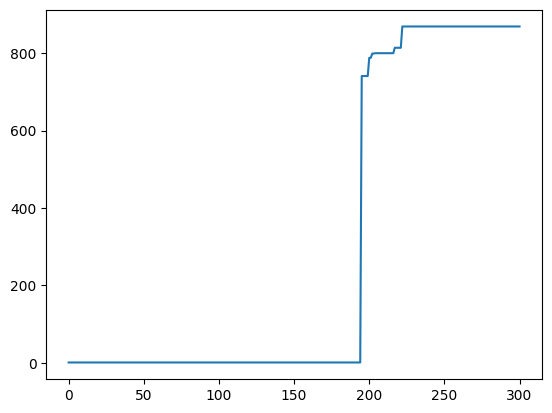

In [136]:
# MUTACION FLIP - 20%
PMUT = 0.2       # taza de mutacion
population = population_init.copy()
# Evolue la poblacion con el algoritmo genetico (cruzamiento 'onepoint', )
best_ind, bestfitness = genetic_algorithm(population, ItemPool, MAX_WEIGHT, GENERATIONS, PMUT, crossover="uniform",
                                          mutation="flip", selection_parents_method = 'roulette', k=3,
                                          selection_survivors_method = 'ranking')

# muestra la evolucion del mejor fitness
plt.plot(bestfitness)
plt.show()

Poblacion inicial, best_fitness = 1
generacion 0, (Mejor fitness = 1)
generacion 61, (Mejor fitness = 797)
generacion 65, (Mejor fitness = 841)
generacion 68, (Mejor fitness = 863)
generacion 72, (Mejor fitness = 919)
generacion 76, (Mejor fitness = 932)
generacion 81, (Mejor fitness = 946)
generacion 82, (Mejor fitness = 953)
generacion 83, (Mejor fitness = 984)
generacion 91, (Mejor fitness = 1001)
generacion 95, (Mejor fitness = 1023)
Mejor individuo en la ultima generacion = [0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1] (fitness = 1023)


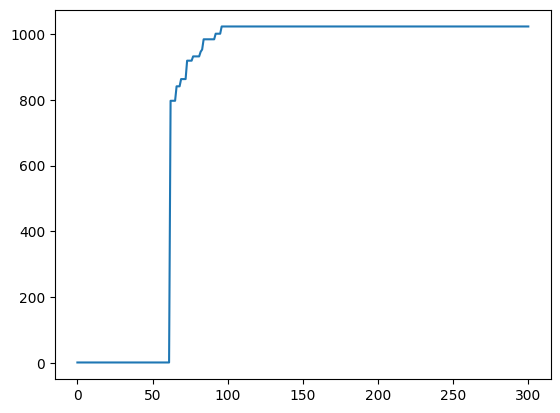

In [138]:
# MUTACION FLIP - 80%
PMUT = 0.8       # taza de mutacion
population = population_init.copy()
# Evolue la poblacion con el algoritmo genetico (cruzamiento 'onepoint', )
best_ind, bestfitness = genetic_algorithm(population, ItemPool, MAX_WEIGHT, GENERATIONS, PMUT, crossover="uniform",
                                          mutation="flip", selection_parents_method = 'roulette', k=50,
                                          selection_survivors_method = 'ranking')

# muestra la evolucion del mejor fitness
plt.plot(bestfitness)
plt.show()

Poblacion inicial, best_fitness = 1
generacion 0, (Mejor fitness = 1)
generacion 73, (Mejor fitness = 669)
generacion 80, (Mejor fitness = 694)
Mejor individuo en la ultima generacion = [0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1] (fitness = 694)


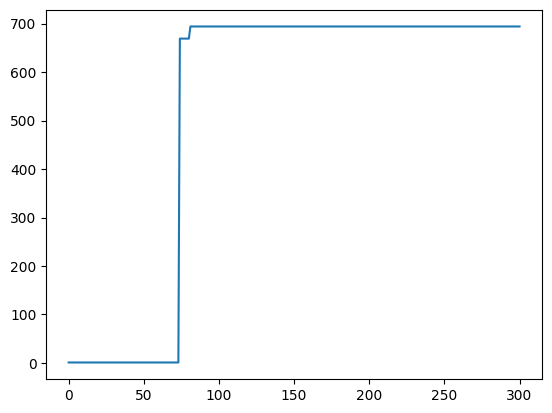

In [131]:
# MUTACION FLIP-K - 20%
PMUT = 0.2       # taza de mutacion
population = population_init.copy()
# Evolue la poblacion con el algoritmo genetico (cruzamiento 'onepoint', )
best_ind, bestfitness = genetic_algorithm(population, ItemPool, MAX_WEIGHT, GENERATIONS, PMUT, crossover="uniform",
                                          mutation="flip_k", selection_parents_method = 'roulette', k=50,
                                          selection_survivors_method = 'ranking')

# muestra la evolucion del mejor fitness
plt.plot(bestfitness)
plt.show()

Poblacion inicial, best_fitness = 1
generacion 0, (Mejor fitness = 1)
generacion 87, (Mejor fitness = 811)
generacion 90, (Mejor fitness = 839)
generacion 92, (Mejor fitness = 881)
generacion 96, (Mejor fitness = 892)
generacion 98, (Mejor fitness = 963)
generacion 105, (Mejor fitness = 999)
generacion 108, (Mejor fitness = 1002)
generacion 119, (Mejor fitness = 1004)
generacion 120, (Mejor fitness = 1020)
generacion 122, (Mejor fitness = 1021)
generacion 123, (Mejor fitness = 1035)
generacion 130, (Mejor fitness = 1051)
generacion 132, (Mejor fitness = 1062)
generacion 145, (Mejor fitness = 1080)
generacion 146, (Mejor fitness = 1081)
generacion 153, (Mejor fitness = 1125)
generacion 212, (Mejor fitness = 1132)
generacion 240, (Mejor fitness = 1166)
Mejor individuo en la ultima generacion = [0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1] (fitness = 1166)

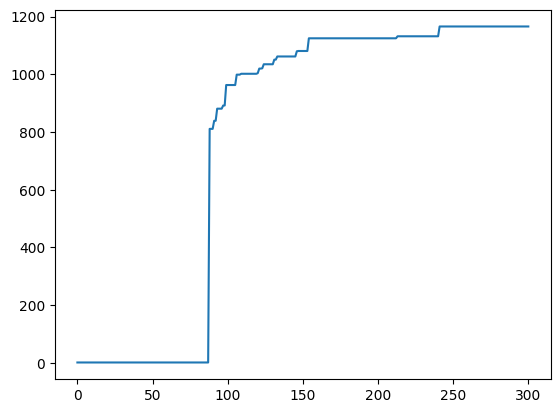

In [137]:
# MUTACION FLIP-K - 80%
PMUT = 0.8       # taza de mutacion
population = population_init.copy()
# Evolue la poblacion con el algoritmo genetico (cruzamiento 'onepoint', )
best_ind, bestfitness = genetic_algorithm(population, ItemPool, MAX_WEIGHT, GENERATIONS, PMUT, crossover="uniform",
                                          mutation="flip_k", selection_parents_method = 'roulette', k=3,
                                          selection_survivors_method = 'ranking')

# muestra la evolucion del mejor fitness
plt.plot(bestfitness)
plt.show()

<b>RESPUESTA</b>

Fitness inicial = 1

HISTORIAL:
1.   Flip (20%)
*   Corr1: Gen75 - Fitness 795
*   Corr2: Gen152 - Fitness 769
*   __Corr3: Gen221 - Fitness 869__

2.   Flip (80%)
*   Corr1: Gen146 - Fitness 1120
*   Corr2: Gen0 - Fitness 1
*   Corr3: Gen176 - Fitness 1021
*   __Corr4: Gen95 - Fitness 1023__

3.   Flip-k (20%)
*   Corr1: Gen45 - Fitness 794
*   Corr2: Gen294 - Fitness 553
*   __Corr3: Gen80 - Fitness 694__

4.   Flip-k (80%)
*   Corr1: Gen253 - Fitness 1145
*   Corr2: Gen162 - Fitness 1151
*   Corr3: Gen0 - Fitness 1
*   __Corr4: Gen240 - Fitness 1166__

Las convergencias con una probabilidad de mutacion del 80% presentan un mayor fitness final, mientras que las que presentan una probablidad menor, son aquellas que tienden a converger rapidamente, aunque a un menor fitness.

El operador de mutacion permite que los individuos muten de diversas formas, en este caso el *flip-k* cambia el invidio en 50 de sus 60 genes, lo cual permite al algoritmo explorar nuevos horitzontes en busca de nuevos máximos locales (para el fitness) y, por ende, conseguir mayores resultados. Mientras que el criterio *flip* solo modifica un gen, siendo un metodo más conservador en el ambito de la exploración. Por otro lado, la tasa de mutación al ser mayor permite que los hijos presenten de manera más continua dichas mutaciones, lo cual permite, a su vez, una exploracion más continua de nuevos picos locales. Lo cual se evidencia, en los resultados de Fitness de Pmut 20% vs 80%, donde al usar un valor de 80% se consiguieron mejores resultados respecto a usar el 20%. Sin embargo, el uso de tasas menores permiten al algoritmo menores (en este caso no es tan evidente por el inicio tan desamparador fit_ini=1 xd) tiempos de convergencia debido a tienden a encasillarse en un unico maximo local, debido a la baja exploracion que se realiza.

Finalmente, los resultados donde no se alcanzo un Fitness mayor al inicial se pueden deber a la funcion de evaluacion, la cual no considera el rendimiento de opciones que se pasen del valor maximo. Es decir, no considera que una opcion con Valor 100 y peso 50 es mejor que una opcion Valor 100 y peso 60, siendo el peso maximo 40. En caso, dicha funcion se adapte, se incurriria una menor captacion de resultados permitiendo que las exploraciones constantes (80%) permitan incluso mejores resultados y no estancarse en el inicial.

In [239]:
def get_fitness(chromosome, items, max_weight):
    """Retorna el fitness del cromosoma pasado. Fitness es el valor total de los items incluidos en el cromosoma
       Si el peso total es mayor que max_weight -> el fitness es 1"""
    fitness = 0 # initialize fitness to 0
    sum_weight = 0
    se_paso = False

    for i in range(len(items)):
        if chromosome[i] == 1:  # si item i esta incluido en cromosoma, acumula su valor y peso
            fitness += items[i].value
            sum_weight += items[i].weight
            if  sum_weight > max_weight: # si se paso del peso maximo retorna 1 como fitness
                se_paso = True
    if se_paso:
      fitness = fitness*(0.01)*(max_weight/sum_weight)


    return fitness

Poblacion inicial, best_fitness = 1
generacion 0, (Mejor fitness = 6.813141683778235)
generacion 1, (Mejor fitness = 7.2486308871851035)
generacion 2, (Mejor fitness = 7.537974683544304)
generacion 3, (Mejor fitness = 8.388017118402283)
generacion 6, (Mejor fitness = 8.583450210378682)
generacion 7, (Mejor fitness = 8.655172413793103)
generacion 9, (Mejor fitness = 8.995633187772928)
generacion 10, (Mejor fitness = 9.128048780487806)
generacion 11, (Mejor fitness = 9.345218800648297)
generacion 13, (Mejor fitness = 977)
Mejor individuo en la ultima generacion = [0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0] (fitness = 977)


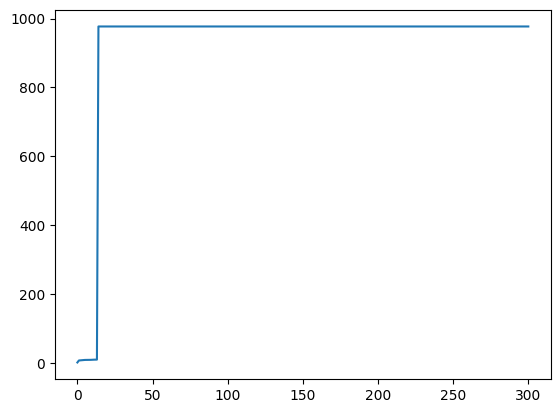

In [248]:
# MUTACION FLIP - 20%
PMUT = 0.2       # taza de mutacion
population = population_init.copy()
# Evolue la poblacion con el algoritmo genetico (cruzamiento 'onepoint', )
best_ind, bestfitness = genetic_algorithm(population, ItemPool, MAX_WEIGHT, GENERATIONS, PMUT, crossover="uniform",
                                          mutation="flip", selection_parents_method = 'roulette', k=3,
                                          selection_survivors_method = 'ranking')

# muestra la evolucion del mejor fitness
plt.plot(bestfitness)
plt.show()

Poblacion inicial, best_fitness = 1
generacion 0, (Mejor fitness = 7.291228070175438)
generacion 2, (Mejor fitness = 7.5438596491228065)
generacion 3, (Mejor fitness = 7.86013986013986)
generacion 4, (Mejor fitness = 8.025974025974026)
generacion 5, (Mejor fitness = 8.113636363636363)
generacion 6, (Mejor fitness = 8.619582664526487)
generacion 7, (Mejor fitness = 902)
generacion 9, (Mejor fitness = 943)
generacion 12, (Mejor fitness = 963)
generacion 13, (Mejor fitness = 968)
generacion 16, (Mejor fitness = 972)
generacion 17, (Mejor fitness = 1022)
generacion 24, (Mejor fitness = 1032)
generacion 26, (Mejor fitness = 1042)
generacion 35, (Mejor fitness = 1049)
generacion 36, (Mejor fitness = 1061)
generacion 37, (Mejor fitness = 1084)
generacion 42, (Mejor fitness = 1087)
Mejor individuo en la ultima generacion = [0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0

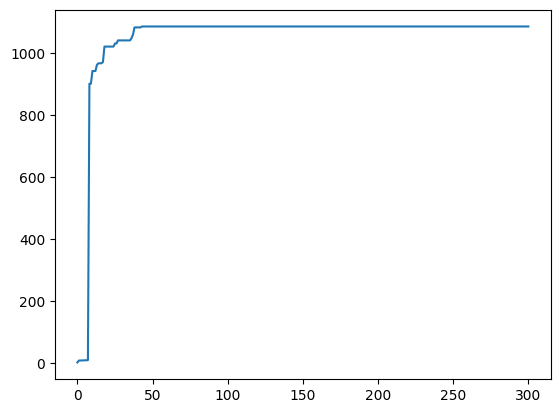

In [258]:
# MUTACION FLIP - 80%
PMUT = 0.8       # taza de mutacion
population = population_init.copy()
# Evolue la poblacion con el algoritmo genetico (cruzamiento 'onepoint', )
best_ind, bestfitness = genetic_algorithm(population, ItemPool, MAX_WEIGHT, GENERATIONS, PMUT, crossover="uniform",
                                          mutation="flip", selection_parents_method = 'roulette', k=50,
                                          selection_survivors_method = 'ranking')

# muestra la evolucion del mejor fitness
plt.plot(bestfitness)
plt.show()

Poblacion inicial, best_fitness = 1
generacion 0, (Mejor fitness = 7.019337016574586)
generacion 1, (Mejor fitness = 7.156626506024097)
generacion 2, (Mejor fitness = 7.332589285714286)
generacion 4, (Mejor fitness = 7.930493273542602)
generacion 6, (Mejor fitness = 8.305084745762713)
generacion 7, (Mejor fitness = 8.566433566433567)
generacion 9, (Mejor fitness = 9.271056661562021)
generacion 12, (Mejor fitness = 911)
generacion 13, (Mejor fitness = 916)
generacion 14, (Mejor fitness = 962)
generacion 17, (Mejor fitness = 966)
generacion 20, (Mejor fitness = 980)
Mejor individuo en la ultima generacion = [1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0] (fitness = 980)


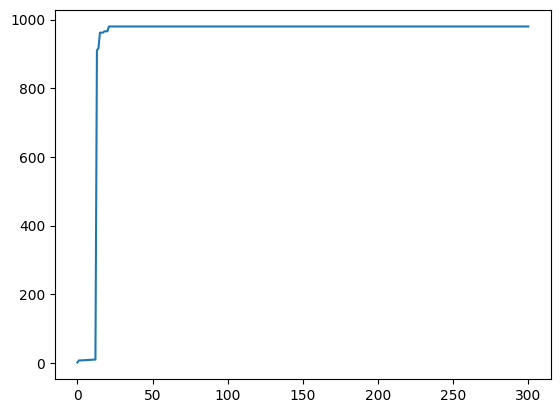

In [250]:
# MUTACION FLIP-K - 20%
PMUT = 0.2       # taza de mutacion
population = population_init.copy()
# Evolue la poblacion con el algoritmo genetico (cruzamiento 'onepoint', )
best_ind, bestfitness = genetic_algorithm(population, ItemPool, MAX_WEIGHT, GENERATIONS, PMUT, crossover="uniform",
                                          mutation="flip_k", selection_parents_method = 'roulette', k=50,
                                          selection_survivors_method = 'ranking')

# muestra la evolucion del mejor fitness
plt.plot(bestfitness)
plt.show()

Poblacion inicial, best_fitness = 1
generacion 0, (Mejor fitness = 6.73992673992674)
generacion 2, (Mejor fitness = 6.945652173913043)
generacion 3, (Mejor fitness = 7.172638436482084)
generacion 5, (Mejor fitness = 7.868702290076335)
generacion 6, (Mejor fitness = 8.291666666666668)
generacion 8, (Mejor fitness = 659)
generacion 9, (Mejor fitness = 699)
generacion 10, (Mejor fitness = 756)
generacion 13, (Mejor fitness = 781)
generacion 14, (Mejor fitness = 815)
generacion 15, (Mejor fitness = 884)
generacion 22, (Mejor fitness = 895)
generacion 23, (Mejor fitness = 897)
generacion 24, (Mejor fitness = 951)
generacion 40, (Mejor fitness = 982)
generacion 43, (Mejor fitness = 991)
generacion 48, (Mejor fitness = 1028)
generacion 53, (Mejor fitness = 1043)
generacion 62, (Mejor fitness = 1068)
generacion 65, (Mejor fitness = 1089)
generacion 114, (Mejor fitness = 1095)
generacion 145, (Mejor fitness = 1113)
generacion 200, (Mejor fitness = 1137)
generacion 201, (Mejor fitness = 1152)
ge

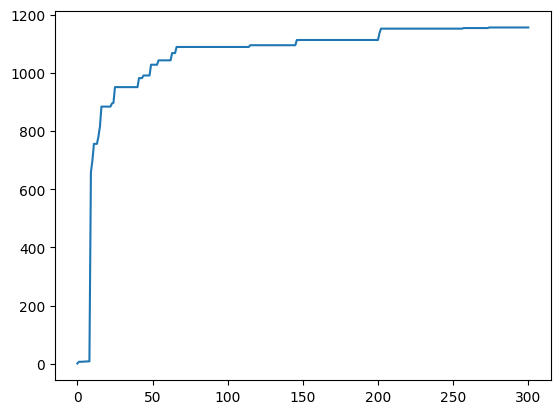

In [254]:
# MUTACION FLIP-K - 80%
PMUT = 0.8       # taza de mutacion
population = population_init.copy()
# Evolue la poblacion con el algoritmo genetico (cruzamiento 'onepoint', )
best_ind, bestfitness = genetic_algorithm(population, ItemPool, MAX_WEIGHT, GENERATIONS, PMUT, crossover="uniform",
                                          mutation="flip_k", selection_parents_method = 'roulette', k=3,
                                          selection_survivors_method = 'ranking')

# muestra la evolucion del mejor fitness
plt.plot(bestfitness)
plt.show()